In [2]:
#setwd("/home/mjehangir/data_analysis/mayo_clinin_project_data_analysis/manuscript_figures/")

In [18]:
data_dir = '/home/mjehangir/glioma_manuscript/manuscript_data/'

In [19]:
setwd(data_dir)

In [20]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)


In [21]:
# Load the Excel file
glioma_data <- read.delim("./clinical_data.txt")

In [22]:
head(glioma_data, n = 21)

,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2436A,NA,3,NA,NA,NA,5,40
2,3188,NA,3,NA,NA,NA,16,107
3,3988,0,2,2,0,0,17,105
4,6265D,33,3,1,0,0,42,87
5,6266D,40,2,1,0,0,28,105
6,6269C,23,3,2,0,0,14,214
7,6277A,40,3,1,0,0,70,138
8,6285B,64,3,1,2,2,7,66
9,6298B,34,3,2,0,2,6,40


In [23]:
# Reorganize columns: Move CDKN2A.B after ATRX
glioma_data <- glioma_data %>%
  select(ID, Age, Grade, TP53, ATRX, CDKN2A.B, onco_Alterations, ONT_Alterations)

# Sort by Grade (placing Grade 2 first)
glioma_data <- glioma_data %>%
  arrange(Grade)

# View the updated dataframe
print(glioma_data)

      ID Age Grade TP53 ATRX CDKN2A.B onco_Alterations ONT_Alterations
1   3988   0     2    0    0        2               17             105
2  6266D  40     2    0    0        1               28             105
3  6314E  25     2    0    2        2               18             226
4  6324B  39     2    0    0        2                4              48
5  6423A  34     2    0    0        2               19             256
6  6436B  34     2    0    2        2               10             132
7  6500D  59     2    0    0        2               13              70
8  2436A  NA     3   NA   NA       NA                5              40
9   3188  NA     3   NA   NA       NA               16             107
10 6265D  33     3    0    0        1               42              87
11 6269C  23     3    0    0        2               14             214
12 6277A  40     3    0    0        1               70             138
13 6285B  64     3    2    2        1                7              66
14 629

In [24]:

#glioma_matrix[] <- lapply(glioma_matrix, as.numeric)  # Convert columns to numeric
#rownames(glioma_matrix) <- glioma_data$ADL.ID  # Set row names to patient IDs


In [25]:
# Convert to a data frame
glioma_matrix <- as.data.frame(glioma_data)
rownames(glioma_matrix) <- glioma_data$ID  # Set row names to patient IDs
print(glioma_matrix$ID)

 [1] "3988"  "6266D" "6314E" "6324B" "6423A" "6436B" "6500D" "2436A" "3188" 
[10] "6265D" "6269C" "6277A" "6285B" "6298B" "6365A" "6414C" "6439C" "6478A"
[19] "6483C" "6605D"


In [26]:
color_palettes <- list(
  Grade = colorRamp2(c(2, 3), c("tomato1", "tomato3")),
  TP53 = colorRamp2(c(0, 1, 2), c("skyblue3", "skyblue", "white")),
  ATRX = colorRamp2(c(0, 1, 2), c("plum4", "plum1", "white")),
  CDKN2A.B = colorRamp2(c(2, 1), c("white", "darkslategray"))
)


In [27]:
# Extract color functions from the color_palettes list
col_Mayo <- color_palettes$Grade
col_TP53 <- color_palettes$TP53
col_ATRX <- color_palettes$ATRX
col_CDKN2A_B <- color_palettes$CDKN2A.B

In [28]:
heatmap_Mayo <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "Grade", drop = FALSE]),
  name = "Grade",
  col = color_palettes$Grade,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  row_names_side = "left",
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add border
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
    # Add value labels

  }
)


heatmap_TP53 <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "TP53", drop = FALSE]),
  name = "TP53",
  col = color_palettes$TP53,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)


heatmap_ATRX <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "ATRX", drop = FALSE]),
  name = "ATRX",
  col = color_palettes$ATRX,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)
heatmap_CDKN2A_B <- Heatmap(
  matrix = as.matrix(glioma_matrix[, "CDKN2A.B", drop = FALSE]),
  name = "CDKN2A/B",
  col = color_palettes$CDKN2A.B,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

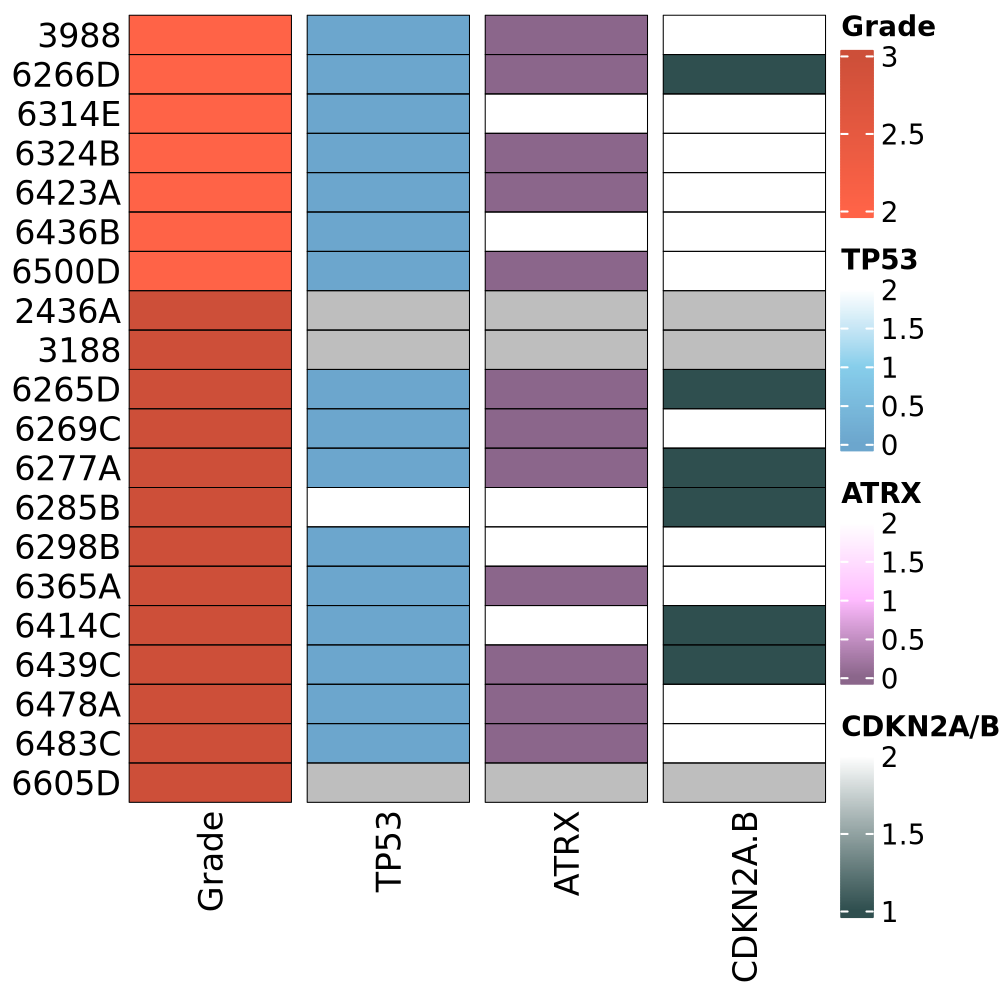

In [29]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

heatmap_Mayo + heatmap_TP53 + heatmap_ATRX +  heatmap_CDKN2A_B 


In [30]:
data_dir1 = '/scratch/mjehangir/Glioma_project/glioma_aneuploidy/'

In [31]:
setwd(data_dir1)

In [32]:
#load the data files

summary_file = read.csv(file = "Glioma_v3_output_taylor_aneuploidy_summary.txt", header = TRUE, sep = "\t")
anueploidy_prop = read.csv(file = "Glioma_v3_output_prop_aneuploidy.txt", header = TRUE, sep = "\t")
taylor_file = read.csv(file = "Glioma_v3_output_taylor_aneuploidy.txt", header = TRUE, sep = "\t")

In [33]:
#extract selected columns to plot heatmaps
summary_file2 = summary_file %>% select("SampleID", "prop_aneuploidy", "aneuploidy_score", "aneuploidy_amp_score", "aneuploidy_del_score")
head(summary_file2)

,SampleID,prop_aneuploidy,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score
,<chr>,<dbl>,<int>,<int>,<int>
1,2436A,0.1274,0,0,0
2,3188,0.8723,8,2,6
3,3988,0.3572,2,1,1
4,6265D,0.6488,0,0,0
5,6266D,0.1347,1,1,0
6,6269C,0.5780,1,1,0


In [34]:
# Define the desired order
desired_order <- c("3988", "6266D", "6314E", "6324B", "6423A", "6436B", "6500D", 
                   "2436A", "3188", "6265D", "6269C", "6277A", "6285B", "6298B", 
                   "6365A", "6414C", "6439C", "6478A", "6483C", "6605D")

# Convert SampleID to a factor with the specified order
summary_file2$SampleID <- factor(summary_file2$SampleID, levels = desired_order)

# Arrange the data based on the new SampleID order
summary_file2 <- summary_file2 %>% arrange(SampleID)

# Check the result
head(summary_file2)

,SampleID,prop_aneuploidy,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score
,<fct>,<dbl>,<int>,<int>,<int>
1,3988,0.3572,2,1,1
2,6266D,0.1347,1,1,0
3,6314E,0.6600,0,0,0
4,6324B,0.3177,1,1,0
5,6423A,0.5448,4,3,1
6,6436B,0.1878,0,0,0


In [35]:
# Extract each column separately for ploting
heatmap_matrix <- summary_file2[, -1] # Remove SampleID column
row.names(heatmap_matrix) <- summary_file2$SampleID

In [36]:
# Define color mappings for heatmaps
color_prop <- colorRamp2(c(0, 1), c("white", "darkgreen"))
color_score <- colorRamp2(c(0, max(heatmap_matrix$aneuploidy_score, na.rm = TRUE)), c("white", "lightseagreen"))
color_amp <- colorRamp2(c(0, max(heatmap_matrix$aneuploidy_amp_score, na.rm = TRUE)), c("white", "darkred"))
color_del <- colorRamp2(c(0, max(heatmap_matrix$aneuploidy_del_score, na.rm = TRUE)), c("white", "darkblue"))


In [37]:
# this function will add border to heatmap tiles
cell_fun = function(j, i, x, y, width, height, fill) {
  grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.7, fill = NA))
}

In [38]:
# Create separate heatmaps files for each column data in ploidy summary file
heatmap_prop <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "prop_aneuploidy", drop = FALSE]),
  name = "Prop. Aneuploidy",
  col = color_prop,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add border
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
    # Add value labels
    grid.text(
      sprintf("%.2f", heatmap_matrix[i, j]), # Format value to 2 decimal places
      x = x, y = y,
      gp = gpar(col = "white", fontsize = 8) # label text inside the boxes with font size 8
    )
  }
)


heatmap_score <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "aneuploidy_score", drop = FALSE]),
  name = "Aneuploidy Score",
  col = color_score,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_amp <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "aneuploidy_amp_score", drop = FALSE]),
  name = "Amp. Score",
  col = color_amp,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)

heatmap_del <- Heatmap(
  matrix = as.matrix(heatmap_matrix[, "aneuploidy_del_score", drop = FALSE]),
  name = "Del. Score",
  col = color_del,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
  }
)


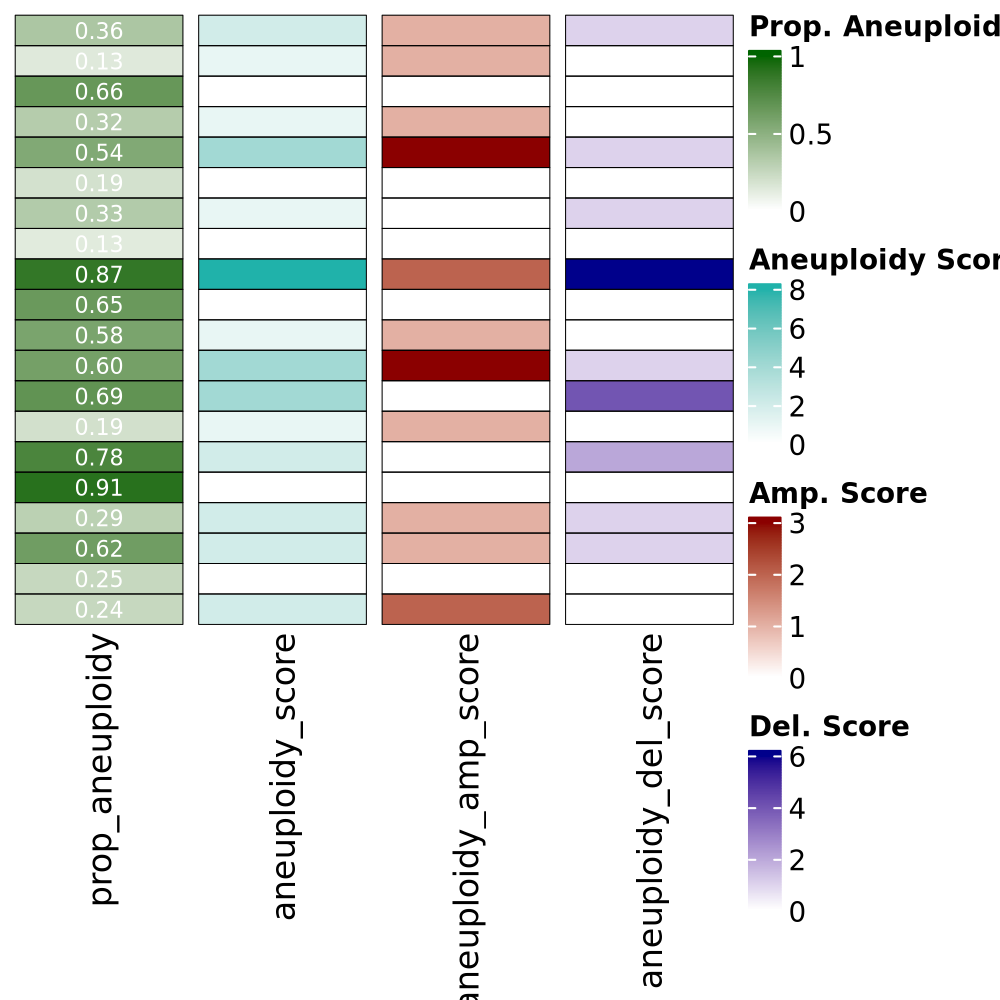

In [39]:
heatmap_prop + heatmap_score + heatmap_amp + heatmap_del

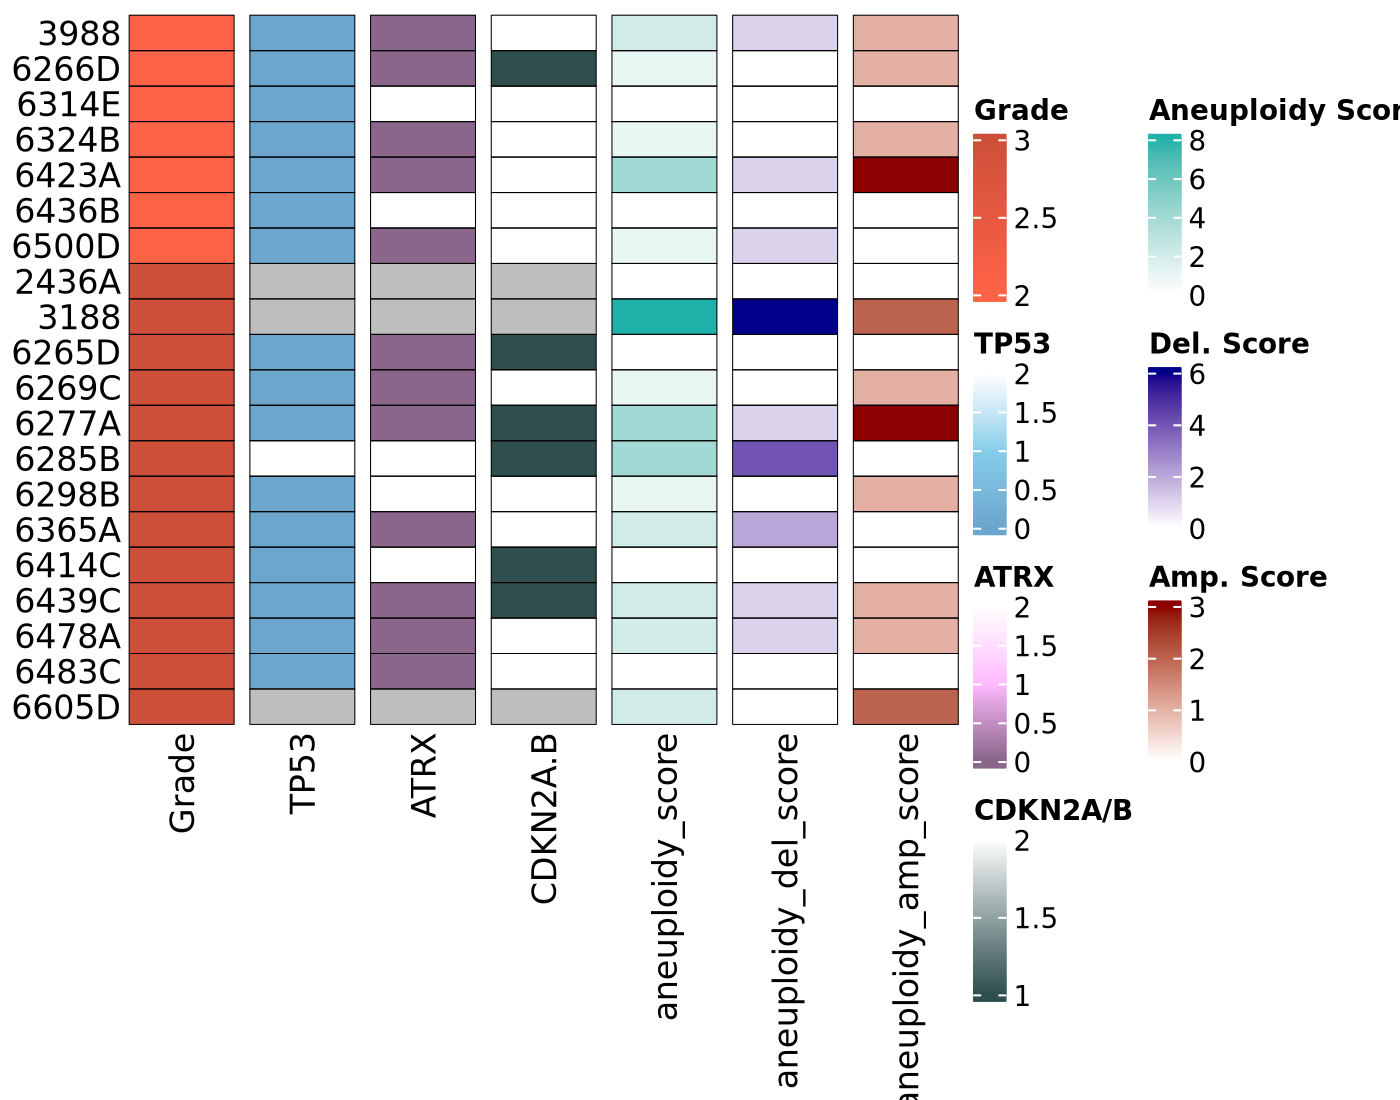

In [40]:

options(repr.plot.width = 7, repr.plot.height = 5.5, repr.plot.res = 200)

heatmap_Mayo + heatmap_TP53 + heatmap_ATRX + heatmap_CDKN2A_B + heatmap_score  + heatmap_del + heatmap_amp

In [41]:
data_dir3 = '/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/'

In [42]:
options(repr.plot.width = 7.5, repr.plot.height = 5.5, repr.plot.res = 200)

pdf(file = "/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/heatmap_clinical_data_combined_v4.pdf", width = 8, height = 6.5)
heatmap_Mayo + heatmap_TP53 + heatmap_ATRX + heatmap_CDKN2A_B + heatmap_score  + heatmap_del + heatmap_amp
dev.off()

pdf 
  2